In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch

##### Define Which Function to Test

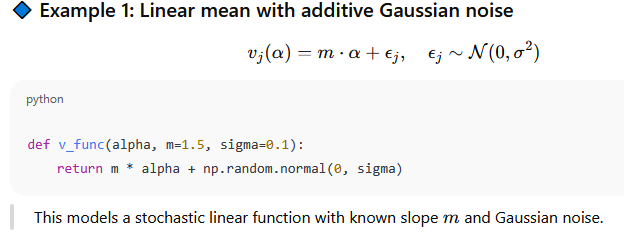

In [2]:
def v_func_Gaus(alpha, m=1.5, sigma=0.1):
    return m * alpha + np.random.normal(0, sigma)

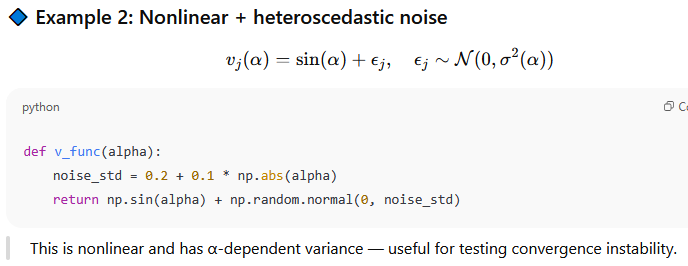

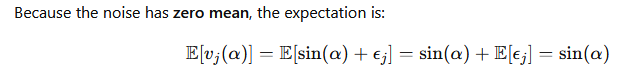

In [3]:
def v_func_NL(alpha):
    noise_std = 0.2 + 0.1 * np.abs(alpha)
    return np.sin(alpha) + np.random.normal(0, noise_std)

This function has no globally uniform expectation function, and may cause unpredictable convergence.

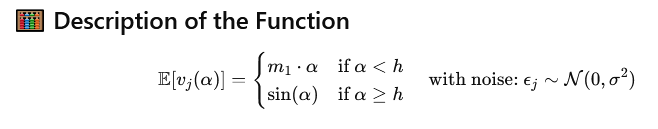

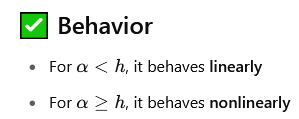

In [ ]:
def sample_v_func_NU(alpha: float, n: int, m1: float = 1.0, h: float = 8.0, sigma: float = 0.1) -> torch.Tensor:
    """
    PyTorch-compatible stochastic function with piecewise expectation.
    This function has no globally uniform expectation function, and may cause unpredictable convergence.

    PyTorch-compatible stochastic function with piecewise expectation:
    E[v_j(α)] = -(α - 5)^2 + 6 for α < h
    E[v_j(α)] = m1*α - 11 for α ≥ h

    Parameters:
        alpha : float       # Current parameter value
        m1    : float       # Linear slope in region α > h
        h     : float       # Breakpoint separating regions
        sigma : float       # Standard deviation of Gaussian noise

    Returns:
        v_j : torch.Tensor  # One sample from v_j(α)
    """
    if isinstance(alpha, torch.Tensor):
        # If alpha is already a tensor, use clone().detach() to avoid warning; else convert from float.
        alpha_tensor = alpha.clone().detach().to(dtype=torch.float32)
    else:
        alpha_tensor = torch.tensor(alpha, dtype=torch.float32)    # ensure it's a float

    if alpha < h:
        mean = -((alpha_tensor - 5) ** 2) + 6
    else:
        mean = m1*alpha_tensor - 11
    
    noise = torch.normal(mean=0.0, std=sigma, size=(n,))
    samples = mean + noise  # broadcasting scalar mean over n noise samples
    return samples  # Return a tensor of a batch of n stochastic samples with torch.Size([1000]). Each sample is: vj​(α) = mean(α) + Gaussian noise

##### Define the Variables Initially

In [4]:
alpha = 1.0  # α: current parameter value (float)
v_d  = 7.0  # v_d: target value (float)
n_ini = 1000  # n_ini: initial number of samples per iteration (int)
lamb = 0.01  # λ: variance penalty weight (float)
gamma = 0.01  # γ: learning rate (float)
ep_tol = 1e-8  # ε: small constant for numerical stability and tolerance (float)
h = 0.1  # h: probing step size for finite difference (float)

In [5]:
n = 1000000
v1 = sample_v_func_NU(alpha=alpha, n=n)  # Sample from linear region

##### Systemic Function Calculation Class Notes

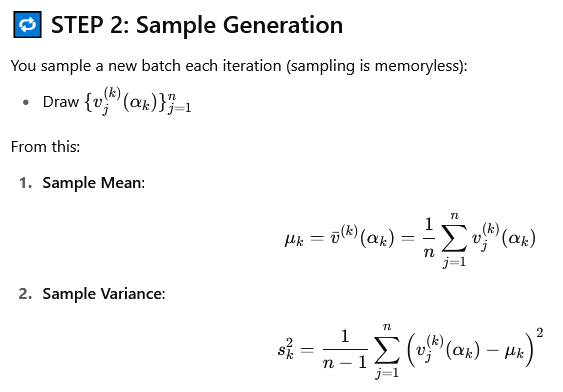

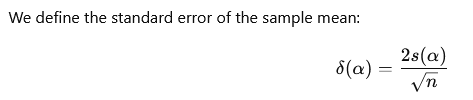

##### Systemic Function Class

In [ ]:
class MacroStats:
    def __init__(self, epsilon=1e-8, slope_tol=0.01, stderr_tol=2.0):
        # Store records as list of dicts with each α and its statistics
        self.records = []  # Each item: {"alpha": α, "mu": μ, "var": s², "stderr": δ}

    def macro_observations(self, alpha: float, samples: torch.Tensor, decimals: int = 6):
        """
        Register a new observation (α, {v_j(α)}), and compute macroscopic statistics.
        Given:
            - α: The current parameter value
            - {v_j(α)}: A batch of n sampled stochastic values at α
        Computes:
            - Sample mean:
                μ(α) ≈ (1/n) ∑_{j=1}^n v_j(α)
            - Sample variance (unbiased estimator):
                s²(α) ≈ (1 / (n - 1)) ∑_{j=1}^n (v_j(α) - μ(α))²
            - Approximate standard error bound (95% confidence):
                This is a confidence bound, based on the approximation that ~95% of sample means (if resampled many times) fall within this range under the Central Limit Theorem as:
                μ ± 2⋅SE(α)
                δ(α) ≈ (2s(α)) / √n
        Stores:
            {"alpha": α, "mu": μ, "var": s², "stderr": δ} as a dict in self.records
        Returns:
            - μ(α), s²(α), δ(α)
        """
        # Round α to consistent float precision
        alpha_rounded = round(float(alpha), decimals)
        alpha_tensor = torch.tensor(alpha_rounded, dtype=torch.float32)
        mu = samples.mean() # Sample mean.
        var = samples.var(unbiased=True) # Sample variance.
        std = torch.sqrt(var) # Sample standard deviation.
        stderr_ci = 2 * std / torch.sqrt(torch.tensor(len(samples), dtype=torch.float32)) # Standard error bound (95% CI).

        
        # Create the record as a dict of torch scalars
        record = {
            "alpha": alpha_tensor,  # Alpha value.
            "n": len(samples),  # Number of samples.
            "mu": mu,  # Sample average.
            "var": var,  # Sample variance.
            "std": std,  # Sample standard deviation
            "stderr_ci": stderr_ci  # Sample standard error bound (95% CI).
        }

        # Check if alpha already exists. If so, replace it.
        for i, r in enumerate(self.records):
            if round(float(r["alpha"]), decimals) == alpha_rounded:
                self.records[i] = record
                break
        else:
            # Update the record within the function.
            self.records.append(record)

        return record  # Optionally return information for inspection.
    
    def suggest_step_size(self, alpha: float, v_d: float, d: int = 1, kappa: float = 100.0, min_h: float = 1e-3) -> float:
        """
        Suggest a finite difference step size h for probing μ(α) with adaptive scaling based on fitness error |μ(α) - v_d|.

        The step size is computed as:
            h = max(sqrt(d + κ) ⋅ s(α) / √n, dynamic_min_h)
        where:
            - d is the dimensionality of the input (default 1).
            - κ is a spread control parameter.
            - σ_α is the estimated standard deviation of the input parameter α.
            - dynamic_min_h increases based on how far μ(α) is from v_d.
        
        Since σ_α is not directly known, it is approximated from the observed output variance
        as:
            σ_α ≈ s(α) / √n
        where s(α) is the sample standard deviation of {v_j(α)}, and n is the sample size.
        Now, the step size is computed as:
            h ≈ sqrt(d + κ) ⋅ s(α) / √n
        Parameters:
            - alpha (float): The parameter location α to retrieve step size for.
            - d (int): Dimension of α, (default 1).
            - kappa (float): Spread parameter controlling sigma point scaling.
            - min_h (float): Floor value to prevent degenerately small step size, (default 1e-3).
        Returns:
            - h (float): Recommended probing step size for finite difference or sigma point generation
        """
        # Specified alpha.
        alpha_tensor = alpha.clone().detach().to(dtype=torch.float32) if isinstance(alpha, torch.Tensor) else torch.tensor(alpha, dtype=torch.float32)
        # Search for matching α
        match = next((r for r in self.records if torch.isclose(r["alpha"], alpha_tensor, atol=1e-6)), None)
        if match is None:
            raise ValueError(f"No statistics found for α = {alpha} in recorded macroscopic observations.")

        s = match["std"]  # Sample standard deviation of v_j(α).
        n = match["n"]  # Sample size at this α (Python int).
        mu = match["mu"]  # Sample average at this α.

        # Dynamically increase floor for step size if far from target
        fitness_error = abs(mu.item() - v_d)

        if fitness_error > 1.0:
            dynamic_min_h = 0.5
        elif fitness_error > 0.1:
            dynamic_min_h = 0.05
        else:
            dynamic_min_h = min_h

        sigma_alpha = s / torch.sqrt(torch.tensor(n, dtype=torch.float32))
        h = torch.sqrt(torch.tensor(d + kappa, dtype=torch.float32)) * sigma_alpha
        h = torch.maximum(h, torch.tensor(dynamic_min_h))

        print(f"sigma_alpha = {sigma_alpha}, fitness_error: |μ(α) - v_d| = {fitness_error}, h = {h}, dynamic_min_h = {dynamic_min_h}")
        return h.item()

In [28]:
# Instantiate the MacroStats class
stats = MacroStats()

##### Plotting Macro Functions and Test Function

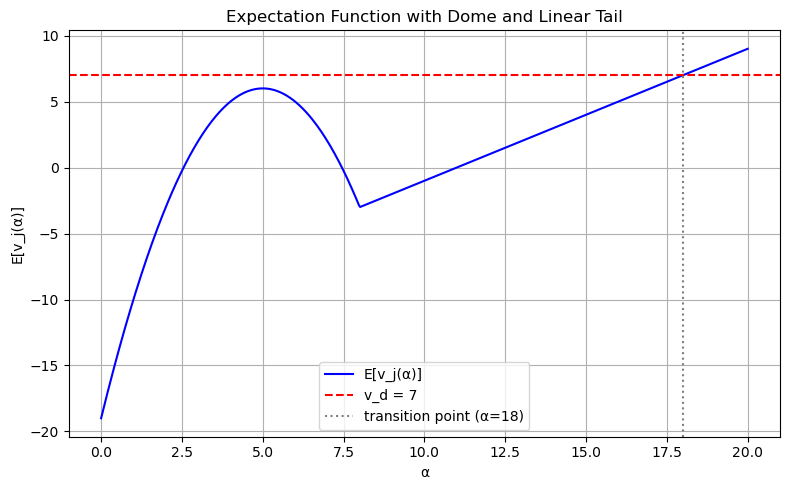

In [13]:
def expected_v_np(alpha):
    return np.where(
        alpha < 8,
        -(alpha - 5) ** 2 + 6,
        alpha - 11
    )

alpha_vals = np.linspace(0, 20, 600)
expectation_vals = expected_v_np(alpha_vals)

plt.figure(figsize=(8, 5))
plt.plot(alpha_vals, expectation_vals, label="E[v_j(α)]", color="blue")
plt.axhline(y=7, color="red", linestyle="--", label="v_d = 7")
intersect = 18
plt.axvline(x=intersect, color="gray", linestyle=":", label=f"transition point (α={intersect})")
plt.title("Expectation Function with Dome and Linear Tail")
plt.xlabel("α")
plt.ylabel("E[v_j(α)]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [31]:
# Define sampling parameters
α_min = 0
α_max = 22
alpha_range = torch.arange(α_min, α_max, step=1.0, dtype=torch.float32)
n = 1000000
# Collect macro observations for each α
for α in alpha_range:
    samples = sample_v_func_NU(alpha=α, n=n)
    stats.macro_observations(alpha=α, samples=samples)

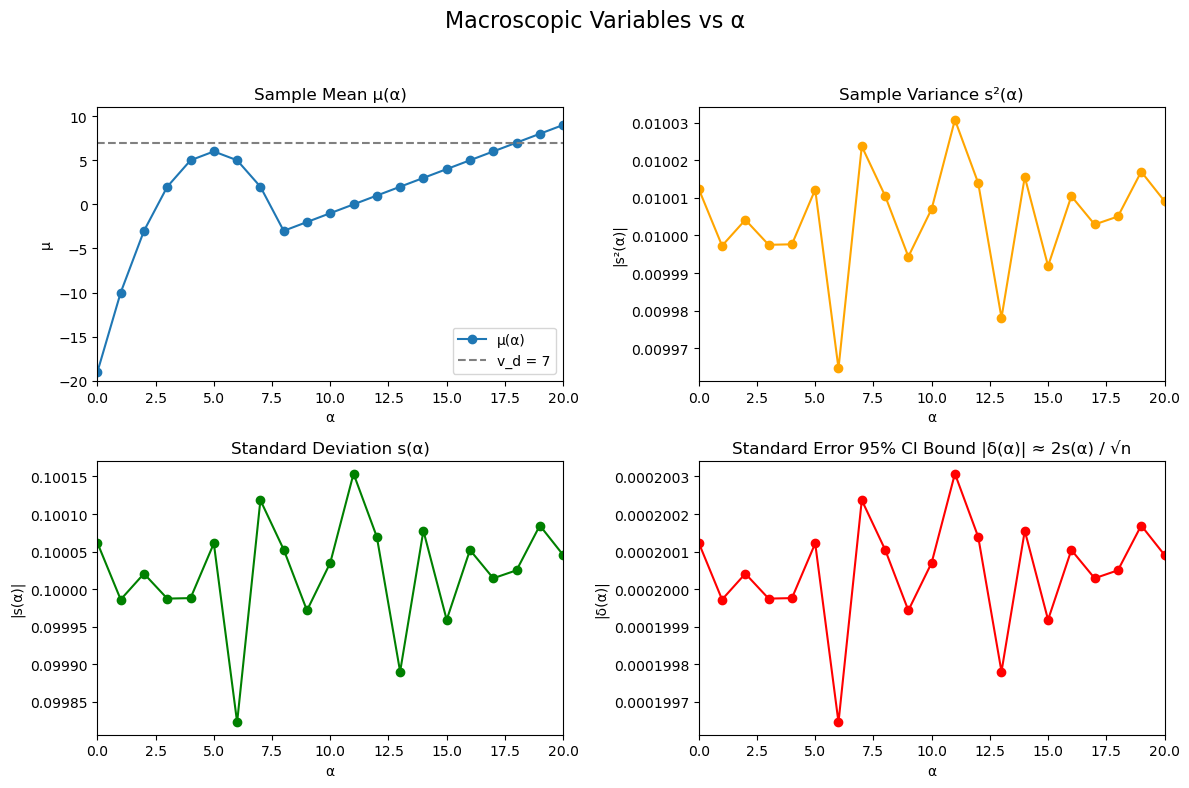

In [33]:
# Extract data from records
alphas = [r["alpha"].item() for r in stats.records]
mus    = [r["mu"].item()     for r in stats.records]
vars_  = [r["var"].item()    for r in stats.records]
stds   = [r["std"].item()    for r in stats.records]
stderrs= [r["stderr_ci"].item() for r in stats.records]

# Define v_d for reference
v_d = 7.0

# Create 2x2 plot
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Macroscopic Variables vs α", fontsize=16)

# Plot 1: μ(α)
axs[0, 0].plot(alphas, mus, marker='o', label='μ(α)')
axs[0, 0].axhline(v_d, color='gray', linestyle='--', label='v_d = 7')
axs[0, 0].set_title("Sample Mean μ(α)")
axs[0, 0].set_xlabel("α")
axs[0, 0].set_ylabel("μ")
axs[0, 0].legend()
axs[0, 0].set_xlim([0, 20])            # Domain
axs[0, 0].set_ylim([min(mus) - 1, max(mus) + 1])  # Range with padding

# Plot 2: s²(α)
axs[0, 1].plot(alphas, vars_, marker='o', color='orange')
axs[0, 1].set_title("Sample Variance s²(α)")
axs[0, 1].set_xlabel("α")
axs[0, 1].set_ylabel("|s²(α)|")
axs[0, 1].set_xlim([0, 20])
# axs[0, 1].set_ylim([min(vars_) - 0.01, max(vars_) + 0.01])

# Plot 3: s(α)
axs[1, 0].plot(alphas, stds, marker='o', color='green')
axs[1, 0].set_title("Standard Deviation s(α)")
axs[1, 0].set_xlabel("α")
axs[1, 0].set_ylabel("|s(α)|")
axs[1, 0].set_xlim([0, 20])
# axs[1, 0].set_ylim([min(stds) - 0.01, max(stds) + 0.01])

# Plot 4: δ(α)
axs[1, 1].plot(alphas, stderrs, marker='o', color='red')
axs[1, 1].set_title("Standard Error 95% CI Bound |δ(α)| ≈ 2s(α) / √n")
axs[1, 1].set_xlabel("α")
axs[1, 1].set_ylabel("|δ(α)|")
axs[1, 1].set_xlim([0, 20])
# axs[1, 1].set_ylim([min(stderrs) - 0.001, max(stderrs) + 0.001])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

##### Step Size Notes

Choose a finite-difference step size h for probing μ(α), large enough that the estimated change in μ is detectable above sample noise, but not so large that it moves into unrelated nonlinear regions.

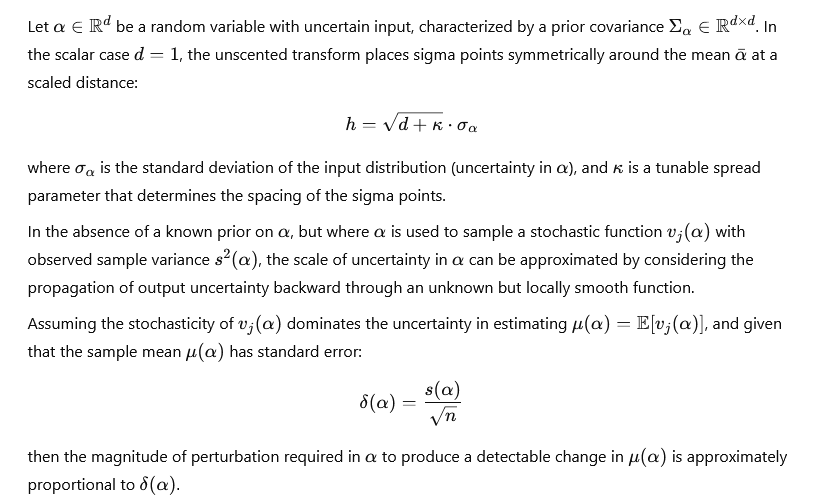

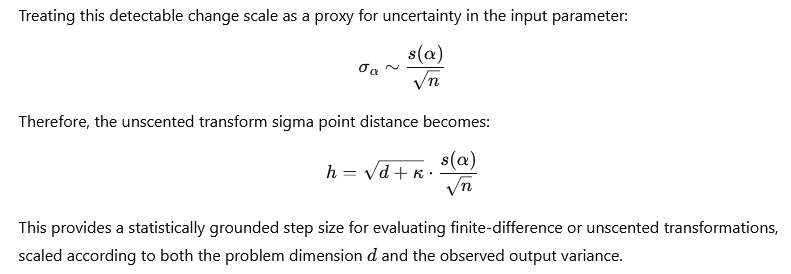

In [53]:
# def suggest_step_size(self, alpha: float, v_d: float, d: int = 1, kappa: float = 100.0, min_h: float = 1e-3) -> float:
#     """
#     Suggest a finite difference step size h for probing μ(α) with adaptive scaling based on fitness error |μ(α) - v_d|.

#     The step size is computed as:
#         h = max(sqrt(d + κ) ⋅ s(α) / √n, dynamic_min_h)
#     where:
#         - d is the dimensionality of the input (default 1).
#         - κ is a spread control parameter.
#         - σ_α is the estimated standard deviation of the input parameter α.
#         - dynamic_min_h increases based on how far μ(α) is from v_d.
    
#     Since σ_α is not directly known, it is approximated from the observed output variance
#     as:
#         σ_α ≈ s(α) / √n
#     where s(α) is the sample standard deviation of {v_j(α)}, and n is the sample size.
#     Now, the step size is computed as:
#         h ≈ sqrt(d + κ) ⋅ s(α) / √n
#     Parameters:
#         - alpha (float): The parameter location α to retrieve step size for.
#         - d (int): Dimension of α, (default 1).
#         - kappa (float): Spread parameter controlling sigma point scaling.
#         - min_h (float): Floor value to prevent degenerately small step size, (default 1e-3).
#     Returns:
#         - h (float): Recommended probing step size for finite difference or sigma point generation
#     """
#     # Specified alpha.
#     alpha_tensor = alpha.clone().detach().to(dtype=torch.float32) if isinstance(alpha, torch.Tensor) else torch.tensor(alpha, dtype=torch.float32)
#     # Search for matching α
#     match = next((r for r in self.records if torch.isclose(r["alpha"], alpha_tensor, atol=1e-6)), None)
#     if match is None:
#         raise ValueError(f"No statistics found for α = {alpha} in recorded macroscopic observations.")


#     # Dynamically increase floor for step size if far from target
#     fitness_error = abs(mu.item() - v_d)

#     if fitness_error > 1.0:
#         dynamic_min_h = 0.5
#     elif fitness_error > 0.1:
#         dynamic_min_h = 0.05
#     else:
#         dynamic_min_h = min_h

#     s = match["std"]  # Sample standard deviation of v_j(α).
#     n = match["n"]  # Sample size at this α (Python int).
#     mu = match["mu"]  # Sample average at this α.

#     sigma_alpha = s / torch.sqrt(torch.tensor(n, dtype=torch.float32))
#     h = torch.sqrt(torch.tensor(d + kappa, dtype=torch.float32)) * sigma_alpha
#     h = torch.maximum(h, torch.tensor(dynamic_min_h))

#     print(f"sigma_alpha = {sigma_alpha}, fitness_error = {fitness_error}, h = {h}, floor = {dynamic_min_h}")
#     return h.item()

# THIS FUNCTION HELPS DETERMINE THE NEXT STEP SIZE USING THE FUNCTION WITHIN THE CLASS macro_stats.
def probe_forward(macro_stats: MacroStats, alpha: float, v_d: float, v_func, n: int) -> float:
    """
    Given current α and a MacroStats object, compute a second α+h and record macro observations at α+h.

    Parameters:
        macro_stats (MacroStats): the statistics tracker
        alpha (float): current α
        v_func (callable): the sampling function to generate v_j(α)
        n (int): number of samples to draw at α+h

    Returns:
        record: the new macro observation dict at α+h
    """
    h = macro_stats.suggest_step_size(alpha, v_d)
    alpha_plus = alpha + h

    samples = v_func(alpha_plus, n)
    record = macro_stats.macro_observations(alpha_plus, samples)
    return record


##### Probe Forward Calculations

In [ ]:
# def get_alpha_pair(stats: MacroStats, alpha_k: float, atol: float = 0.01):
#     """
#     Retrieves the RECORDS for α_k and α_k+1 (i.e. α_k + h), assuming stats.records is sorted.

#     Parameters:
#         stats (MacroStats): The statistics object
#         alpha_k (float): The α_k value
#         atol (float): Tolerance for float comparison

#     Returns:
#         rec_k (dict): record at α_k
#         rec_kp1 (dict): record at α_k + h
#     """
#     alpha_k_tensor = torch.tensor(alpha_k, dtype=torch.float32)

#     # Find the index of the exact match
#     index = next(
#         (i for i, r in enumerate(stats.records) if torch.isclose(r["alpha"], alpha_k_tensor, atol=atol)),
#         None
#     )
#     if index is None:
#         raise ValueError(f"No record found for alpha_k = {alpha_k}")

#     rec_k = stats.records[index]

#     # Get the next record to the right in the sorted list
#     if index + 1 >= len(stats.records):
#         raise ValueError(f"No α_k+1 found after α_k = {alpha_k}")
#     rec_kp1 = stats.records[index + 1]

#     return rec_k, rec_kp1

##### Finite Difference Calculations Class

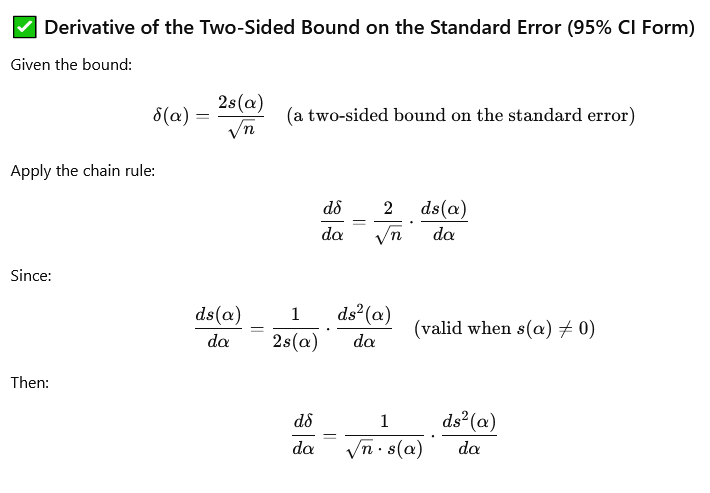

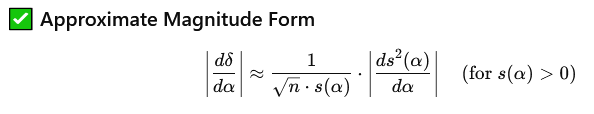

In [ ]:
class FiniteDifferenceTracker:
    def __init__(self, epsilon, slope_tol, stderr_tol):
        self.fd_records = []  # Each: {"alpha_k": α_k, "alpha_k+1": α_k+1, "dmu_dalpha": ..., "dvar_dalpha": ..., "h": ...}
        # Store Polyak–Ruppert slope history as torch tensor list
        self.slope_history = []  # list of torch scalars
        # Parameters for stability, tolerance, confidence
        self.epsilon = epsilon                    # numerical stability (denominator guard)
        self.slope_tol = slope_tol                # convergence threshold for m_k
        self.stderr_tol = stderr_tol              # multiplier for stderr-based agreement
        # Most recent slope estimate
        self.m_k = None  ## type: torch.Tensor or None

    @staticmethod
    def get_alpha_pair(stats: MacroStats, alpha_k: float, atol: float = 0.01):
        """
        Retrieves the RECORDS for α_k and α_k+1 (i.e. α_k + h), assuming stats.records is sorted.

        Parameters:
            stats (MacroStats): The statistics object
            alpha_k (float): The α_k value
            atol (float): Tolerance for float comparison

        Returns:
            rec_k (dict): record at α_k
            rec_kp1 (dict): record at α_k + h
        """
        alpha_k_tensor = torch.tensor(alpha_k, dtype=torch.float32)
        
        # Ensure records are sorted by alpha
        stats.records.sort(key=lambda r: r["alpha"].item())

        # Find the index of the exact match
        index = next(
            (i for i, r in enumerate(stats.records) if torch.isclose(r["alpha"], alpha_k_tensor, atol=atol)),
            None
        )
        if index is None:
            raise ValueError(f"No record found for alpha_k = {alpha_k}")

        rec_k = stats.records[index]

        # Get the next record to the right in the sorted list
        if index + 1 >= len(stats.records):
            raise ValueError(f"No α_k+1 found after α_k = {alpha_k}")
        rec_kp1 = stats.records[index + 1]

        return rec_k, rec_kp1
    
    def compute_and_store(self, rec_k: dict, rec_kp1: dict, decimals: int = 6):
        """
        Computes finite difference estimates between two macro records:
            - dμ/dα ≈ (μ_k+1 - μ_k) / (α_k+1 - α_k)
            - ds²/dα ≈ (s²_k+1 - s²_k) / (α_k+1 - α_k)

        This function also stores the result in self.fd_records for later reference.

        Parameters:
            rec_k (dict): Record at α_k
            rec_kp1 (dict): Record at α_k + h
            decimals (int): Rounding precision for α identifiers

        Returns:
            dict with:
                - 'alpha_pair': tuple of (α_k, α_k+1)
                - 'dmu_dalpha': float
                - 'dvar_dalpha': float
                - 'h': float (step size used)
        """
        α_k = round(float(rec_k["alpha"]), decimals)
        α_kp1 = round(float(rec_kp1["alpha"]), decimals)
        h = α_kp1 - α_k

        if abs(h) < 1e-12:
            raise ValueError("Finite difference step h is effectively zero.")

        dmu = (rec_kp1["mu"] - rec_k["mu"]) / h
        dvar = (rec_kp1["var"] - rec_k["var"]) / h

        fd_record = {
            "alpha_k": α_k, 
            "alpha_k+1": α_kp1,
            "dmu_dalpha": dmu.item(),
            "dvar_dalpha": dvar.item(),
            "h": h
        }

        self.fd_records.append(fd_record)
        return fd_record
    
    def compute_all_differences(self, stats: 'MacroStats', decimals: int = 6):
        """
        Fully recomputes all finite differences between adjacent α values in stats.records.
        Clears fd_records and repopulates it cleanly.
        Uses function compute_and_store(self) to populate fd_records.

        Parameters:
            stats (MacroStats): The macro-level statistics tracker.
            decimals (int): Rounding precision for α comparison.
        """
        self.fd_records.clear() # Clear out old
        # Sort stats.records by α (in-place)
        stats.records.sort(key=lambda r: round(float(r["alpha"]), decimals))

        for i in range(len(stats.records) - 1):
            rec_k = stats.records[i]
            rec_kp1 = stats.records[i + 1]
            try:
                self.compute_and_store(rec_k, rec_kp1, decimals=decimals)
            except ValueError as e:
                print(f"Skipping invalid α pair ({rec_k['alpha']}, {rec_kp1['alpha']}): {e}")
    
    def estimate_derivative_at(self, alpha: float, kind: str = "mu", decimals: int = 6):
        """
        Estimates the derivative (mean or variance) at a specific α using surrounding finite differences.
        If both left and right intervals exist, average them. Otherwise, use whichever exists.

        Parameters:
            alpha (float): The α value at which to estimate the derivative.
            kind (str): Either "mu" or "var".
            decimals (int): Precision for float matching.

        Returns:
            float or None: Estimated slope at α
        """
        alpha = round(alpha, decimals)
        left = None
        right = None

        for fd in self.fd_records:
            a_k = round(fd["alpha_k"], decimals)
            a_kp1 = round(fd["alpha_kp1"], decimals)

            if a_kp1 == alpha:
                left = fd
            elif a_k == alpha:
                right = fd

        key = "dmu_dalpha" if kind == "mu" else "dvar_dalpha"

        if left and right:
            return 0.5 * (left[key] + right[key])
        elif right:
            return right[key]
        elif left:
            return left[key]
        else:
            return None  # No estimate available

##### Loss Function and Derivative

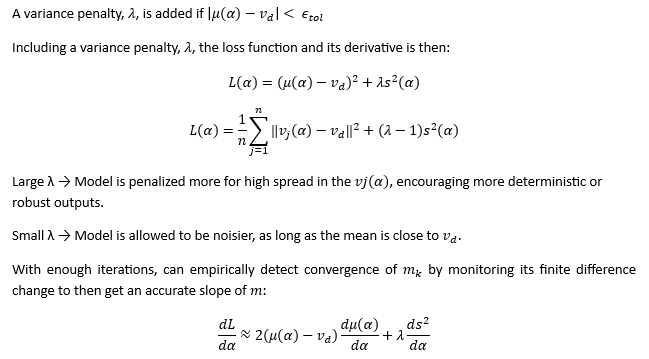

In [55]:
def decide_next_alpha(alpha_k: float,
                      rec_k: dict,
                      rec_kp1: dict,
                      fd_results: dict,
                      v_d: float,
                      lamb: float = 0.01,
                      gamma: float = 1.0,
                      slope_tol: float = 1e-3,
                      fitness_tol: float = 0.1,
                      clip_max_step: float = 1.0) -> float:
    """
    Decide the next alpha value based on loss gradient, fitness comparison, and slope behavior.

    Parameters:
        alpha_k (float): current α
        rec_k (dict): macro record at α_k
        rec_kp1 (dict): macro record at α_k + h
        fd_results (dict): finite difference results with dmu/dα, dvar/dα, h
        v_d (float): target value
        λ (float): variance penalty weight
        γ (float): learning rate multiplier
        slope_tol (float): threshold for detecting slope collapse
        fitness_tol (float): tolerance for saying we're "close" to target
        clip_max_step (float): maximum allowed update magnitude (safety, early in training, gradients can be very steep).

    Returns:
        alpha_next (float): suggested next α
    """
    mu_k = rec_k["mu"]
    mu_kp1 = rec_kp1["mu"]
    dmu_dalpha = fd_results["dmu_dalpha"]
    dvar_dalpha = fd_results["dvar_dalpha"]
    h = fd_results["h"]

    # Gradient estimate of the loss
    dL_dalpha = 2 * (mu_k - v_d) * dmu_dalpha + lamb * dvar_dalpha
    print(f"dL/dα = {dL_dalpha}")

    # Fitness improvement check
    fitness_k = abs(mu_k - v_d)
    fitness_kp1 = abs(mu_kp1 - v_d)

    print(f"At α_k = {alpha_k}, |mu(α_k) - vd| = {fitness_k}")
    print(f"At α_k+1 = {alpha_k + h}, |mu(α_k) - vd| = {fitness_kp1}")
    print(f"|dμ/dα| = {dmu_dalpha}")

    # Slope collapse + far from target = likely trapped near peak
    if abs(dmu_dalpha) < slope_tol and fitness_k > fitness_tol:
        print("Override: slope too small, far from target → stepping forward")
        return alpha_k + h  # override with forward probe

    # Fitness override: go to α + h if it's closer to target
    if fitness_kp1 < fitness_k:
        print("Override: fitness improves at α + h → stepping forward")
        return alpha_k + h

    # Otherwise: follow gradient (with clipping)
    step = -gamma * dL_dalpha * h  # Adding 'h' makes the step size consistent with how gradient was estimated.
    step = max(min(step, clip_max_step), -clip_max_step)
    print(f"Follow α_k+1 = α_k + dL/dα with clipping = {step}")
    return alpha_k + step

##### Custom Sweep and Sign Tracking

In [35]:
def detect_sign_transitions(stats: MacroStats, v_d: float, atol: float = 1e-6):
    """
    Detects intervals in α where the sign of (μ(α) - v_d) changes between consecutive records.

    This function scans through the recorded macro statistics (stats.records) and checks for sign changes
    in the deviation of the sample mean μ(α) from the target value v_d. A sign change indicates
    a crossing point where μ(α) - v_d switches from positive to negative or vice versa.

    This is useful for identifying bracketing intervals around roots or peaks in the expectation
    landscape where the function crosses the desired target level.

    Parameters:
        stats (MacroStats): The macro statistics object containing sampled μ(α) values.
        v_d (float): The target value against which μ(α) is compared.
        atol (float): Absolute tolerance for floating-point equality when comparing α values.

    Returns:
        transitions (List[Tuple[float, float]]): A list of tuples (α_left, α_right) marking
        intervals where the sign of (μ(α) - v_d) changes.
    """
    transitions = []
    for i in range(1, len(stats.records)):
        mu_i, mu_prev = stats.records[i]["mu"], stats.records[i-1]["mu"]
        sign_i = torch.sign(mu_i - v_d).item()
        sign_prev = torch.sign(mu_prev - v_d).item()
        if sign_i != sign_prev:
            α_left = stats.records[i-1]["alpha"].item()
            α_right = stats.records[i]["alpha"].item()
            transitions.append((α_left, α_right))
    return transitions

##### Testing Algorithm Iteration

In [65]:
# Initialize macro stats tracker and FD tracker
stats = MacroStats()
fd_tracker = FiniteDifferenceTracker(epsilon=1e-8, slope_tol=0.01, stderr_tol=2.0)

In [66]:
# Define sampling parameters
α_min = 0
α_max = 22
alpha_range = torch.arange(α_min, α_max, step=1.0, dtype=torch.float32)
n = 1000000
# Collect macro observations for each α
for α in alpha_range:
    samples = sample_v_func_NU(alpha=α, n=n)
    stats.macro_observations(alpha=α, samples=samples)

In [67]:
fd_tracker.compute_all_differences(stats)

In [71]:
# Instert another value and test fd_tracker.compute_all_differences()
α_insert = 10.5
samples_insert = sample_v_func_NU(alpha=α_insert, n=n)
stats.macro_observations(alpha=α_insert, samples=samples_insert)
# Recompute all differences
fd_tracker.compute_all_differences(stats)
# Verify new intervals
for fd in fd_tracker.fd_records:
    if abs(fd["alpha_k"] - 10.0) < 1e-6 or abs(fd["alpha_k"] - 10.5) < 1e-6:
        print(fd)

{'alpha_k': 10.0, 'alpha_k+1': 10.5, 'dmu_dalpha': 1.0003904104232788, 'dvar_dalpha': 7.07581639289856e-05, 'h': 0.5}
{'alpha_k': 10.5, 'alpha_k+1': 11.0, 'dmu_dalpha': 0.9995381236076355, 'dvar_dalpha': -1.8922612071037292e-05, 'h': 0.5}


In [73]:
for fd in fd_tracker.fd_records[:]:
    print(fd)

{'alpha_k': 0.0, 'alpha_k+1': 1.0, 'dmu_dalpha': 9.000085830688477, 'dvar_dalpha': -1.3925135135650635e-05, 'h': 1.0}
{'alpha_k': 1.0, 'alpha_k+1': 2.0, 'dmu_dalpha': 6.999985694885254, 'dvar_dalpha': 1.2166798114776611e-05, 'h': 1.0}
{'alpha_k': 2.0, 'alpha_k+1': 3.0, 'dmu_dalpha': 4.999907493591309, 'dvar_dalpha': -1.0146759450435638e-05, 'h': 1.0}
{'alpha_k': 3.0, 'alpha_k+1': 4.0, 'dmu_dalpha': 3.0000436305999756, 'dvar_dalpha': 2.5141984224319458e-05, 'h': 1.0}
{'alpha_k': 4.0, 'alpha_k+1': 5.0, 'dmu_dalpha': 0.9998960494995117, 'dvar_dalpha': -6.576068699359894e-06, 'h': 1.0}
{'alpha_k': 5.0, 'alpha_k+1': 6.0, 'dmu_dalpha': -0.9999198913574219, 'dvar_dalpha': -9.624287486076355e-06, 'h': 1.0}
{'alpha_k': 6.0, 'alpha_k+1': 7.0, 'dmu_dalpha': -3.000114917755127, 'dvar_dalpha': -1.6427598893642426e-05, 'h': 1.0}
{'alpha_k': 7.0, 'alpha_k+1': 8.0, 'dmu_dalpha': -4.999783039093018, 'dvar_dalpha': 3.770366311073303e-05, 'h': 1.0}
{'alpha_k': 8.0, 'alpha_k+1': 9.0, 'dmu_dalpha': 1.00001

In [41]:
alpha = 1.0  # α: current parameter value (float)
v_d  = 7.0  # v_d: target value (float)
n_ini = 1000  # n_ini: initial number of samples per iteration (int)
lamb = 0.01  # λ: variance penalty weight (float)
gamma = 0.01  # γ: learning rate (float)
ep_tol = 1e-8  # ε: small constant for numerical stability and tolerance (float)
h = 0.1  # h: probing step size for finite difference (float)

In [49]:
# Call the sign transition detector
transitions = detect_sign_transitions(stats, v_d=v_d)

# Print results
print(f"Detected sign transitions of μ(α) - v_d:")
for left, right in transitions:
    print(f"  Transition interval: α ∈ ({left:.6f}, {right:.6f})")
    alpha_k = left
    print(f"alpha_k = {alpha_k}")

Detected sign transitions of μ(α) - v_d:
  Transition interval: α ∈ (17.000000, 18.000000)
alpha_k = 17.0


In [56]:
# Step 1: Sample at α_k
samples = sample_v_func_NU(alpha=alpha_k, n=n)
stats.macro_observations(alpha=alpha_k, samples=samples)

# Step 2: Get step size based on fitness
h = stats.suggest_step_size(alpha=alpha_k, v_d=v_d)

# Step 3: Sample at α_k + h
samples_plus = sample_v_func_NU(alpha=alpha_k + h, n=n)
stats.macro_observations(alpha=alpha_k + h, samples=samples_plus)

# Step 4: Get records and finite diffs
rec_k, rec_kp1 = get_alpha_pair(stats, alpha_k=alpha_k)
fd_results = finite_differences(rec_k, rec_kp1)

# Step 5: Decide next α
alpha_next = decide_next_alpha(alpha_k=alpha_k,
                                rec_k=rec_k,
                                rec_kp1=rec_kp1,
                                fd_results=fd_results,
                                v_d=v_d,
                                lamb=lamb,
                                gamma=gamma)
print(f"α_k+1 = {alpha_next}")

sigma_alpha = 9.974619752028957e-05, fitness_error: |μ(α) - v_d| = 0.9999608993530273, h = 0.05000000074505806, dynamic_min_h = 0.05
dL/dα = -2.000046968460083
At α_k = 17.0, |mu(α_k) - vd| = 0.9999608993530273
At α_k+1 = 18.0, |mu(α_k) - vd| = 0.00010204315185546875
|dμ/dα| = 1.0000629425048828
Override: fitness improves at α + h → stepping forward
α_k+1 = 18.0
